<a href="https://colab.research.google.com/github/Goutham-26/DSA/blob/main/Case_Study_on_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset House_Pricing.csv


In [7]:
data=pd.read_csv('/content/House_Pricing .csv')
data

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


Display basic information about the dataset using .info() and .describe() to understand the features, data types, and any initial insights into missing values.


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [9]:
data.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Duplicate Removal


Rows: Check for duplicate rows in the dataset, if any, and remove them.


In [10]:
data.duplicated().sum()

np.int64(0)

Columns: Identify and drop duplicate columns, if any, based on their values.


In [11]:
data.columns.duplicated().sum()

np.int64(0)

Handling Missing Values


Identify missing values in each column.


In [12]:
data.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


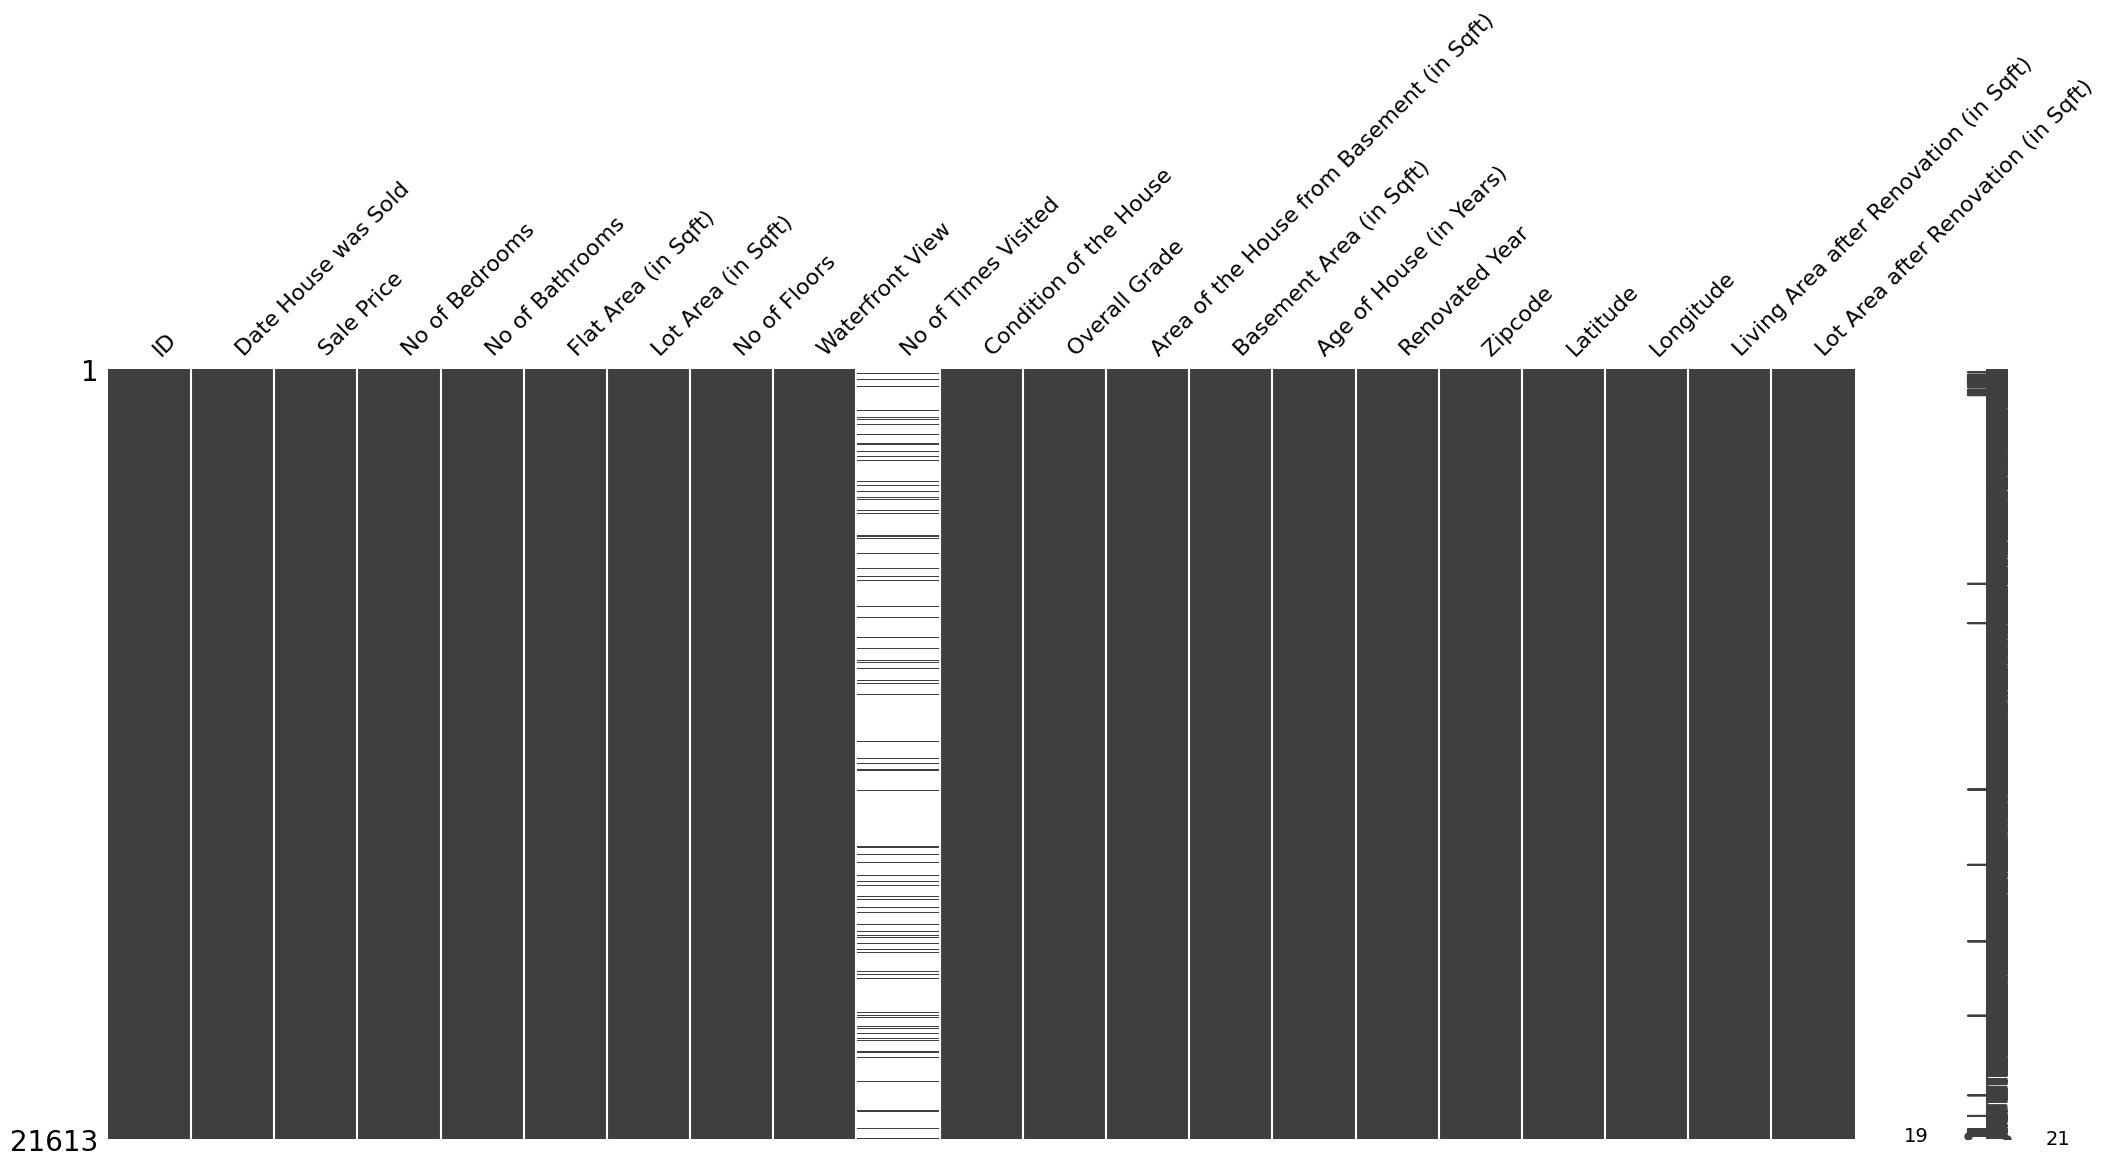

In [13]:
import missingno as msno
msno.matrix(data)
plt.show()

Handle missing values:

For numerical columns, use imputation techniques like mean/median imputation.

For categorical columns, fill with mode.


In [14]:
data = data.fillna(data.mean(numeric_only = True))
data.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [15]:
data['No of Times Visited'] = data['No of Times Visited'].fillna(data['No of Times Visited'].mode()[0])
data.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,0


Outlier Removal


Perform an outlier detection analysis on numerical variables (e.g., using the IQR method).

Remove outliers from these features if they are not representative of typical house prices.


In [16]:
numeric_col = data.select_dtypes(include = ['int64','float64']).columns.drop(['Sale Price','ID'],errors='ignore')
numeric_col

Index(['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

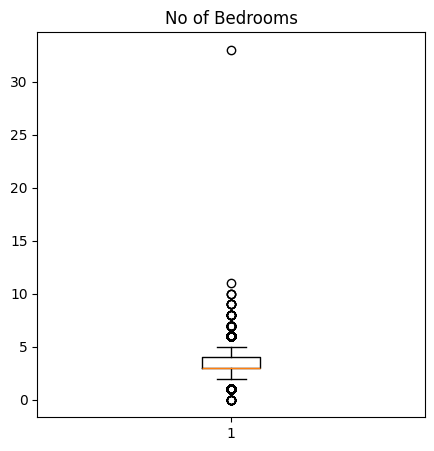

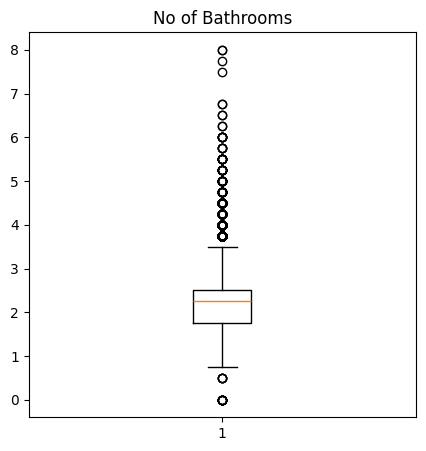

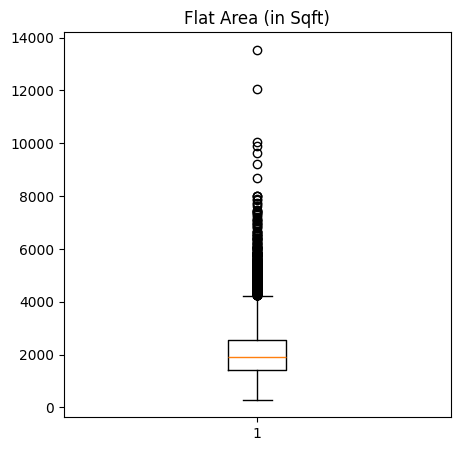

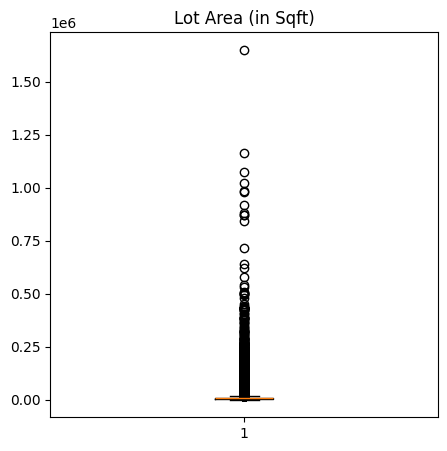

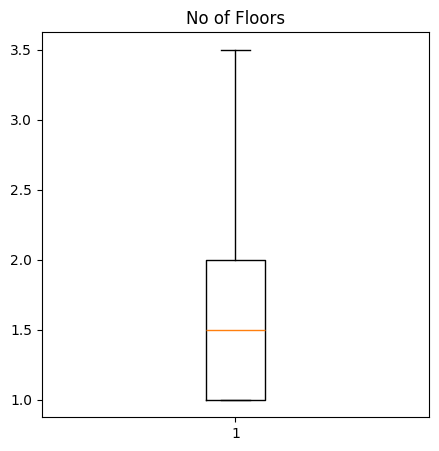

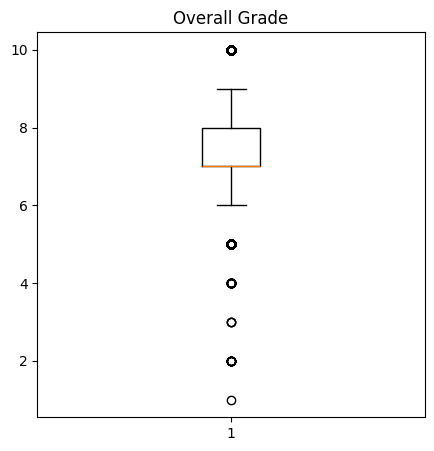

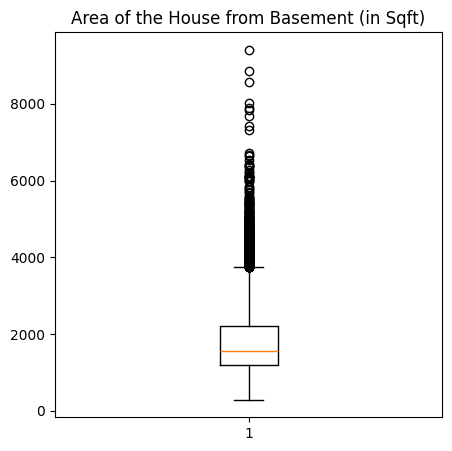

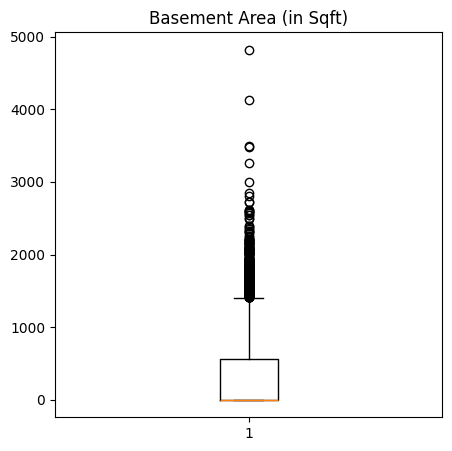

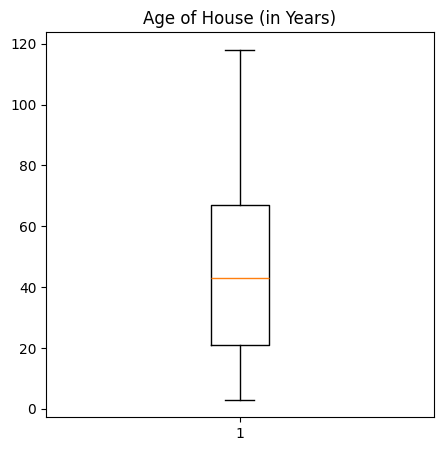

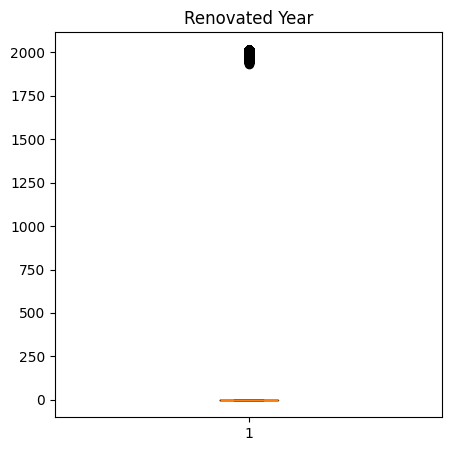

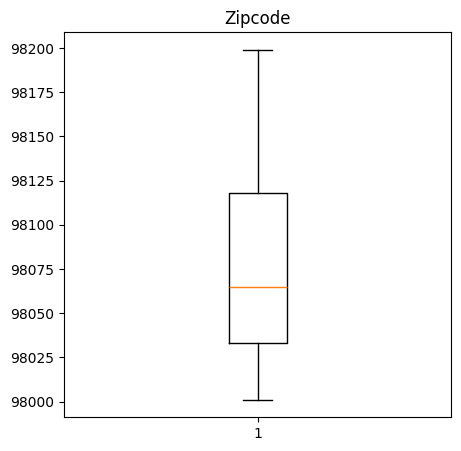

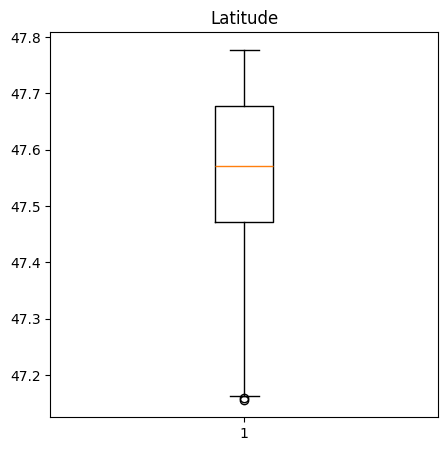

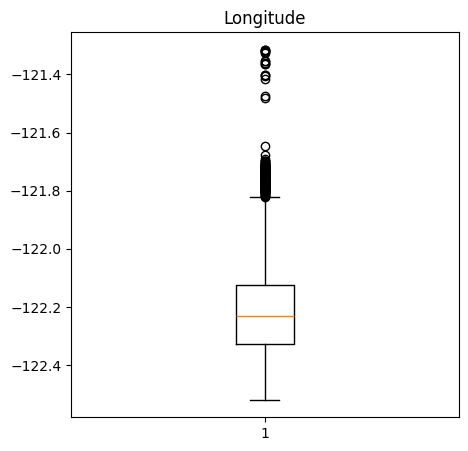

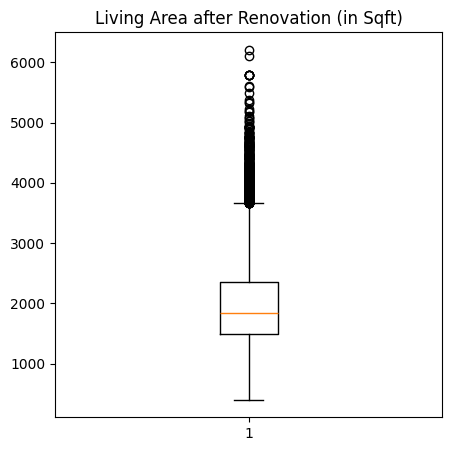

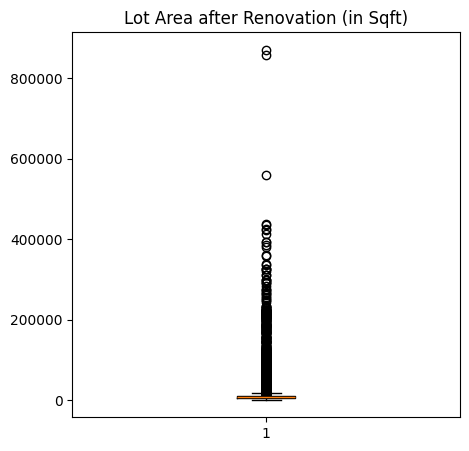

In [17]:
for i in numeric_col:
  plt.figure(figsize=(5,5))
  plt.boxplot(data[i])
  plt.title(i)

In [18]:
Q1 = data['No of Bedrooms'].quantile(0.25)
Q3 = data['No of Bedrooms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)

3.0 4.0 1.0 1.5 5.5


In [19]:
for x in data['No of Bedrooms']:
  if x <lower_bound or x > upper_bound:
    print(x)


1
6
6
6
1
6
1
1
6
6
7
6
1
6
6
6
6
1
0
1
1
7
1
6
6
6
6
7
6
6
6
1
1
6
1
6
6
6
6
6
1
1
8
6
6
6
1
6
6
6
1
1
1
6
1
1
1
6
6
1
6
6
6
6
6
6
6
6
6
6
6
6
6
6
1
6
6
6
6
6
1
1
1
1
6
1
0
6
1
6
1
1
1
6
1
0
1
6
6
6
1
1
6
6
1
6
7
6
6
6
1
1
1
6
6
1
1
7
8
8
1
9
6
1
6
9
6
6
6
1
1
1
6
6
6
1
6
6
6
7
7
1
7
0
1
6
1
6
6
6
1
6
6
1
6
6
6
6
6
6
1
1
1
1
1
6
6
9
1
1
1
6
8
6
6
6
6
1
6
6
6
1
1
6
6
0
1
7
6
6
6
7
6
1
6
6
1
6
1
1
6
6
6
6
6
1
1
6
6
6
6
1
1
1
6
7
1
6
1
6
1
6
1
6
6
6
1
0
0
7
1
1
9
1
1
1
7
6
6
1
11
1
1
6
1
6
1
6
8
6
6
6
1
7
6
1
6
6
1
6
6
1
8
1
6
1
1
1
6
6
6
7
6
6
7
0
6
6
6
1
1
6
0
1
6
6
1
1
6
6
1
6
7
1
1
1
6
6
7
1
8
6
6
6
6
6
6
6
1
6
1
1
6
1
1
6
1
6
6
1
1
6
6
1
6
6
6
1
6
7
1
6
1
1
1
6
1
6
6
6
1
1
6
1
1
1
7
7
0
7
1
7
1
6
1
1
1
6
8
6
1
6
7
6
10
1
6
6
6
6
1
1
6
1
6
1
6
6
6
7
1
6
1
7
6
6
1
1
1
1
1
6
0
1
1
6
6
6
6
1
6
7
6
7
6
8
6
6
10
1
6
7
1
6
1
6
6
7
6
6
8
6
7
6
1
6
1
33
6
6
6
6
7
6
1
1
6
1
6
6
1
6
7
6
1
1
9
1
6
1
6
6
6
8
1
7
6
1
1
6
6
1
6
1
1
6
6
1
6
1
6
1
1
6
1
1
1
6
6
1
6
1
0
6
9
7
8
1
1
1
6
6
6
1
7
1
6
6


{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d79917a10>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d799179b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d79914890>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d79917da0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d799600b0>],
 'means': []}

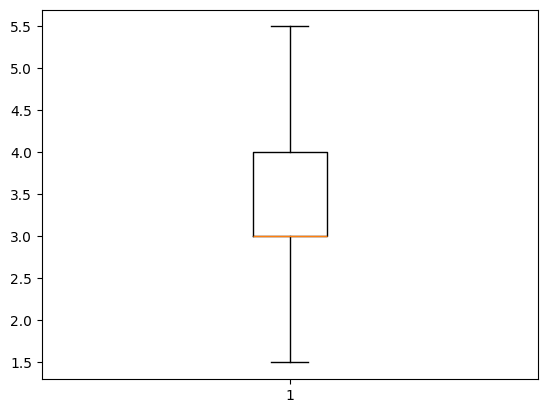

In [20]:
data['No of Bedrooms'] = data['No of Bedrooms'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['No of Bedrooms'])


In [21]:
Q1 = data['No of Bathrooms'].quantile(0.25)
Q3 = data['No of Bathrooms'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)


1.75 2.5 0.75 0.625 3.625


In [22]:
for x in data['No of Bathrooms']:
  if x <lower_bound or x > upper_bound:
    print(x)


4.5
4.0
4.0
4.75
5.0
4.25
4.5
4.25
3.75
5.0
4.0
4.0
4.25
4.25
0.0
4.25
4.5
4.5
3.75
4.5
4.0
0.0
4.5
5.25
4.0
3.75
4.5
4.5
4.25
6.0
3.75
4.25
4.0
3.75
3.75
4.75
5.0
3.75
3.75
3.75
5.0
4.25
3.75
4.0
4.25
4.5
3.75
4.0
3.75
5.0
3.75
4.0
3.75
3.75
4.25
4.0
4.25
4.25
4.5
3.75
4.0
3.75
5.0
3.75
0.5
4.0
5.0
5.0
4.5
5.5
4.25
4.0
4.5
3.75
3.75
4.5
3.75
5.5
4.25
5.5
0.0
5.25
4.25
4.0
4.5
3.75
3.75
3.75
3.75
4.25
4.5
4.75
3.75
3.75
3.75
3.75
3.75
4.5
4.25
4.0
4.75
4.75
3.75
4.5
4.0
3.75
3.75
4.0
4.0
3.75
4.75
4.5
3.75
6.75
6.0
4.5
5.5
4.5
3.75
4.0
4.25
3.75
5.75
3.75
4.0
4.0
4.0
5.25
4.75
4.0
4.25
3.75
4.0
4.0
5.25
3.75
3.75
3.75
4.5
5.0
3.75
3.75
4.5
4.0
3.75
3.75
4.0
4.75
3.75
0.0
4.25
5.0
3.75
4.0
4.25
4.0
4.0
4.5
4.75
4.0
4.0
4.0
4.5
3.75
3.75
4.5
5.75
4.75
3.75
4.0
4.0
3.75
4.25
4.25
3.75
0.0
4.5
5.5
4.0
4.5
4.5
4.0
4.5
4.25
8.0
3.75
4.25
4.0
3.75
4.5
3.75
4.5
4.5
4.5
4.0
4.25
5.0
4.5
4.25
4.5
6.75
4.0
3.75
4.5
4.25
3.75
4.5
3.75
3.75
4.0
7.5
4.0
4.0
4.0
4.25
3.75
4.5
3.75
4.25
4.25
4.5
4.5
4

{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d7999b260>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d7999b7d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d7999af90>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d7999bd70>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d799d00e0>],
 'means': []}

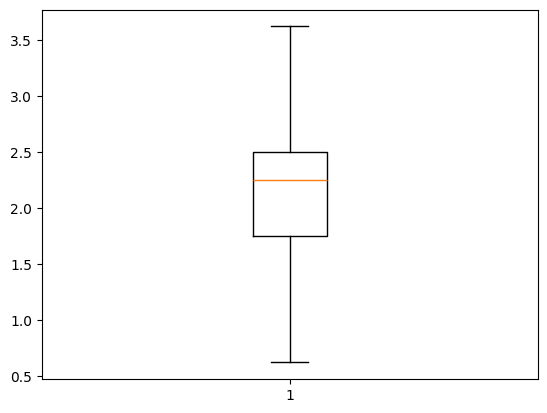

In [23]:
data['No of Bathrooms'] = data['No of Bathrooms'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['No of Bathrooms'])


In [24]:
Q1 = data['Flat Area (in Sqft)'].quantile(0.25)
Q3 = data['Flat Area (in Sqft)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)


1430.0 2550.0 1120.0 -250.0 4230.0


In [25]:
for x in data['Flat Area (in Sqft)']:
  if x<lower_bound or x>upper_bound:
    print(x)


5420.0
4770.0
4380.0
5180.0
4410.0
5050.0
5310.0
4550.0
4290.0
4290.0
4800.0
6070.0
4870.0
4860.0
4860.0
4410.0
4760.0
6050.0
4740.0
5403.0
4380.0
4640.0
6050.0
4370.0
4570.0
4670.0
4860.0
4270.0
4890.0
4390.0
4250.0
5670.0
4475.0
6070.0
4300.0
4390.0
8010.0
4460.0
4610.0
4380.0
4250.0
4930.0
7390.0
4640.0
5320.0
8000.0
6563.0
4740.0
5450.0
4440.0
4830.0
4280.0
4570.0
4370.0
5710.0
5620.0
5774.0
4470.0
4490.0
5040.0
5770.0
5180.0
6400.0
4490.0
6055.0
4250.0
6300.0
4350.0
4460.0
4340.0
4250.0
5110.0
4700.0
4910.0
4750.0
6840.0
4930.0
5180.0
5130.0
6640.0
5740.0
7350.0
4510.0
4300.0
4870.0
5020.0
4740.0
5370.0
4860.0
6930.0
6550.0
6110.0
4883.0
5010.0
4660.0
4600.0
4910.0
5410.0
4270.0
4520.0
5340.0
5230.0
5370.0
4730.0
4430.0
5780.0
6240.0
10040.0
4250.0
5360.0
4610.0
7480.0
5620.0
4340.0
7080.0
5760.0
4400.0
4280.0
9200.0
4320.0
4420.0
4380.0
4580.0
5310.0
4660.0
4300.0
4240.0
5180.0
6810.0
4690.0
5830.0
4930.0
5700.0
5990.0
5070.0
4750.0
4270.0
4750.0
5040.0
4890.0
4350.0
4280.0
6390.

{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d798123f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d798129f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d79812120>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d79812f90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d79813230>],
 'means': []}

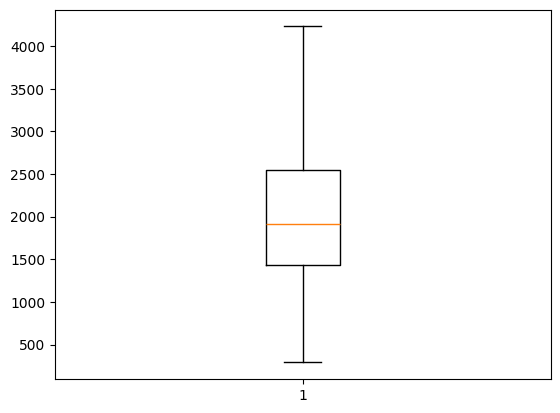

In [26]:
data['Flat Area (in Sqft)'] = data['Flat Area (in Sqft)'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['Flat Area (in Sqft)'])


In [27]:
Q1 = data['Lot Area (in Sqft)'].quantile(0.25)
Q3 = data['Lot Area (in Sqft)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)


5040.0 10701.0 5661.0 -3451.5 19192.5


In [28]:
for x in data['Lot Area (in Sqft)']:
  if x <lower_bound or x > upper_bound:
    print(x)


101930.0
19901.0
44867.0
34848.0
24186.0
65005.0
21235.0
20158.0
50094.0
50529.0
35102.0
39683.0
41800.0
36847.0
107593.0
33919.0
28037.0
111078.0
315374.0
60984.0
19850.0
25245.0
38332.0
21000.0
35003.0
66211.0
155073.0
33474.0
19436.0
28040.0
94300.0
221284.0
36224.0
40510.0
20100.0
57346.0
26300.0
49375.0
22111.0
78408.0
64904.0
45004.0
43995.0
20000.0
32633.0
19800.0
77972.0
29970.0
40438.0
69415.0
209959.0
26977.0
25600.0
22357.0
40139.0
143947.0
32239.0
37461.0
174240.0
171626.0
27260.0
19700.0
219978.0
24920.0
20978.0
28025.0
181319.0
19635.0
57063.0
39150.0
194278.0
230652.0
36947.0
76230.0
24069.0
40518.0
29242.0
29170.0
108900.0
217014.0
22370.0
75794.0
84942.0
217800.0
32666.0
31465.0
34293.0
26326.0
36400.0
55867.0
22267.0
209523.0
19252.0
23488.0
25958.0
26055.0
39478.0
51836.0
37769.0
72745.0
22594.0
218252.0
31400.0
23680.0
40419.0
34133.0
36276.0
40097.0
36085.0
57381.0
24931.0
25600.0
30736.0
35287.0
23899.0
213444.0
25341.0
28243.0
50308.0
262018.0
35026.0
22410.0
479

{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d79872510>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d79872990>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d79872240>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d79872f30>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d79873260>],
 'means': []}

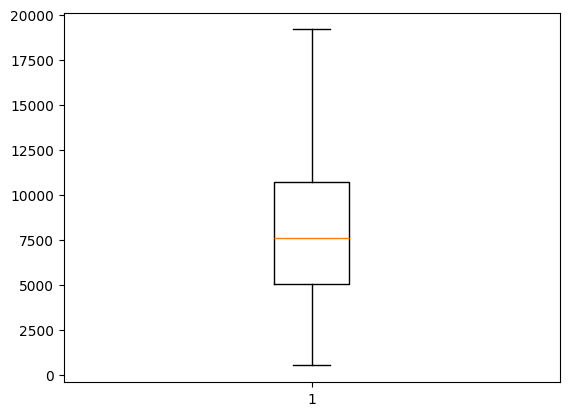

In [29]:
data['Lot Area (in Sqft)'] = data['Lot Area (in Sqft)'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['Lot Area (in Sqft)'])

In [30]:
Q1 = data['Overall Grade'].quantile(0.25)
Q3 = data['Overall Grade'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)

7.0 8.0 1.0 5.5 9.5


In [31]:
for x in data['Overall Grade']:
  if x <lower_bound or x > upper_bound:
    print(x)


10
5
10
10
10
10
10
10
10
10
5
10
10
10
10
10
10
5
5
10
10
10
10
10
10
10
4
10
10
10
10
10
10
5
10
10
10
10
10
10
10
4
10
10
5
10
10
10
10
5
10
10
10
10
10
10
10
10
10
10
10
10
10
10
5
5
10
10
10
10
10
10
10
10
5
5
5
10
10
10
10
10
10
10
5
10
10
10
10
10
10
4
10
5
10
10
10
5
10
5
10
3
10
10
10
5
10
10
10
10
10
10
10
10
10
10
10
10
10
5
10
10
10
10
10
10
10
5
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
5
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
5
10
5
10
10
10
10
10
10
5
10
10
10
10
10
10
10
10
10
5
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
10
5
10
10
5
10
10
10
10
10
5
10
10
10
10
10
10
10
10
10
10
10
5
10
10
5
10
10
5
10
10
10
10
10
3
10
10
5
10
10
10
10
5
5
10
10
10
5
10
10
10
10
10
10
5
5
10
10
10
10
5
10
10
10
10
10
4
10
10
5
5
10
10
10
10
10
10
10
10
10
10
10
10
10
10
5
5
10
10
10
10
5
5
4
10
10
10
10
10
10
5
10
10
5
10
5
10
10
10
10
10
10
10
5
10
10
10
5
10

{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d798e2240>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d798e2810>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d798be690>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d798e2e10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d798e3050>],
 'means': []}

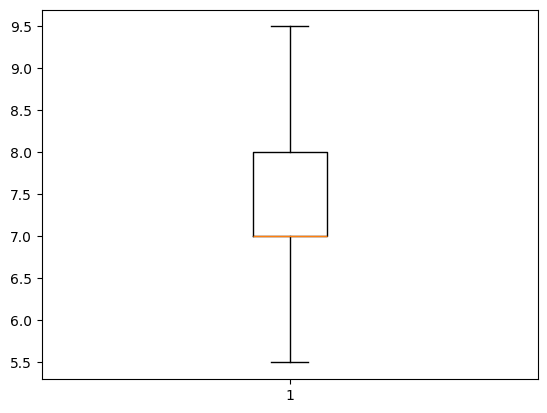

In [32]:
data['Overall Grade'] = data['Overall Grade'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['Overall Grade'])

In [33]:
Q1 = data['Area of the House from Basement (in Sqft)'].quantile(0.25)
Q3 = data['Area of the House from Basement (in Sqft)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)

1190.0 2210.0 1020.0 -340.0 3740.0


In [34]:
for x in data['Area of the House from Basement (in Sqft)']:
  if x <lower_bound or x > upper_bound:
    print(x)


3890.0
3760.0
4750.0
5310.0
3840.0
6070.0
4040.0
3840.0
4860.0
3860.0
4410.0
6050.0
4740.0
5403.0
4120.0
4150.0
4370.0
4570.0
4670.0
4230.0
4270.0
5670.0
4475.0
6070.0
4300.0
3990.0
5990.0
4460.0
4190.0
4250.0
4930.0
3840.0
5000.0
5320.0
6720.0
4210.0
3890.0
3830.0
5153.0
4210.0
4740.0
5450.0
4280.0
3880.0
4570.0
3750.0
4130.0
5710.0
4700.0
3810.0
4490.0
4150.0
4070.0
3840.0
5770.0
4030.0
3810.0
4490.0
3840.0
4360.0
3960.0
4460.0
4340.0
3850.0
4750.0
4350.0
4160.0
5180.0
4070.0
5130.0
6350.0
3770.0
3780.0
4750.0
3950.0
3915.0
3880.0
4870.0
4030.0
4740.0
3850.0
4860.0
4310.0
3930.0
4070.0
4080.0
5400.0
6110.0
3859.0
4600.0
3940.0
3800.0
4230.0
4070.0
5050.0
4000.0
4220.0
3860.0
3890.0
3890.0
5230.0
5370.0
4140.0
4270.0
4430.0
4210.0
4130.0
3780.0
4610.0
7680.0
4250.0
3820.0
4120.0
3770.0
4610.0
5080.0
4140.0
4340.0
3770.0
5760.0
4390.0
4000.0
3810.0
4400.0
6200.0
4320.0
4380.0
4040.0
4580.0
4180.0
4240.0
4070.0
6110.0
4115.0
3780.0
3830.0
3780.0
5830.0
4140.0
3920.0
3930.0
5990.0
5070.0

{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d79742f60>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d79743560>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d79742c30>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d79743b90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d79743e30>],
 'means': []}

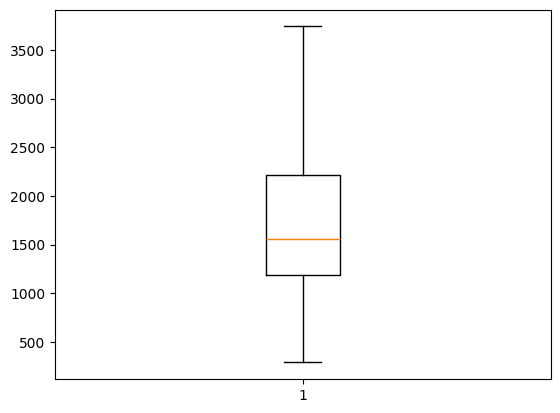

In [35]:
data['Area of the House from Basement (in Sqft)'] = data['Area of the House from Basement (in Sqft)'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['Area of the House from Basement (in Sqft)'])

In [36]:
Q1 = data['Basement Area (in Sqft)'].quantile(0.25)
Q3 = data['Basement Area (in Sqft)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)

0.0 560.0 560.0 -840.0 1400.0


In [37]:
for x in data['Basement Area (in Sqft)']:
  if x <lower_bound or x > upper_bound:
    print(x)


1530
1700
1620
1510
1600
1700
1600
1490
1640
1460
2000
1430
1950
2060
1820
1450
1950
1600
1600
1580
1470
1780
1900
1450
1760
1600
1720
1760
1510
1800
1810
1460
1830
1590
1620
1420
1960
1560
2020
2110
1490
2390
1600
1780
2020
1700
1410
1450
1500
1800
1580
1800
1480
1670
1510
1800
1620
2570
2110
1490
2590
1580
1480
1410
1480
2500
1940
1550
2350
2490
1481
1470
1520
1850
1830
1660
2130
2600
1450
1850
1690
1850
1600
1520
1780
2620
1600
1430
1798
2060
1610
1780
1440
1590
1500
1450
1600
1690
1500
1470
1570
1590
1650
1500
1510
1910
1630
2360
1852
2090
2400
1480
1790
2150
1500
1440
1500
1430
1720
1500
1410
1680
2100
3000
1870
1530
1420
1460
1710
1640
1500
1410
2030
1650
1820
1540
1540
1710
1460
2850
1610
1800
1660
1420
1420
2170
1450
2150
1560
1560
1830
1720
1460
1590
1670
1500
1530
1430
1500
1530
2170
1940
2040
1800
1490
1750
1570
1420
1460
2030
2720
1720
1420
1660
1610
1460
1500
2730
1720
1440
1590
1480
1450
1420
1840
3480
1440
1540
1790
1490
1540
1680
2160
1430
1690
1450
1650
1700
1870
1920


{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d797ade80>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d797ae450>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d797adb20>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d797ae9f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d797aed20>],
 'means': []}

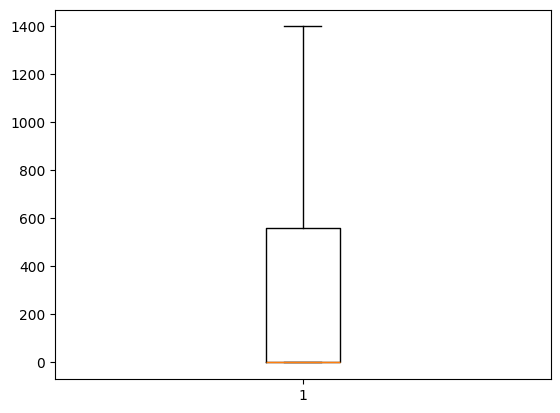

In [38]:
data['Basement Area (in Sqft)'] = data['Basement Area (in Sqft)'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['Basement Area (in Sqft)'])

In [39]:
Q1 = data['Living Area after Renovation (in Sqft)'].quantile(0.25)
Q3 = data['Living Area after Renovation (in Sqft)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)


1490.0 2360.0 870.0 185.0 3665.0


In [40]:
for x in data['Living Area after Renovation (in Sqft)']:
  if x <lower_bound or x > upper_bound:
    print(x)


4760.0
4110.0
3740.0
3836.0
3890.0
4180.0
3920.0
4550.0
3860.0
3860.0
4050.0
4680.0
3930.0
4300.0
3850.0
4210.0
3980.0
3920.0
3715.0
4190.0
4230.0
3890.0
4100.0
4090.0
3680.0
4100.0
3720.0
4750.0
3950.0
5790.0
3890.0
4320.0
4640.0
3970.0
4600.0
3950.0
5600.0
3820.0
3950.0
3720.0
4800.0
3990.0
3720.0
3860.0
3900.0
3720.0
4060.0
3910.0
3730.0
3760.0
3910.0
3770.0
3960.0
4620.0
4050.0
3860.0
3730.0
4470.0
4890.0
3690.0
3680.0
3780.0
3980.0
3690.0
4240.0
3890.0
4670.0
4050.0
4350.0
5380.0
4330.0
3830.0
5000.0
3680.0
4250.0
4080.0
4110.0
4190.0
3770.0
3736.0
4600.0
3980.0
4170.0
4090.0
3750.0
3680.0
4630.0
3910.0
3880.0
4110.0
3960.0
3710.0
3930.0
4170.0
3721.0
3930.0
4650.0
4020.0
3920.0
3900.0
4470.0
3680.0
3710.0
4240.0
4020.0
3920.0
4320.0
3770.0
4190.0
3720.0
4230.0
3960.0
3950.0
3740.0
3740.0
3670.0
4080.0
5340.0
4440.0
3690.0
4690.0
4920.0
4160.0
3810.0
4480.0
3880.0
3690.0
3990.0
4050.0
5790.0
5330.0
3930.0
3920.0
4010.0
4700.0
4090.0
3750.0
3930.0
3820.0
4100.0
3720.0
3750.0
3880.0

{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d75a4a3f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d75a4a990>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d75a4a120>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d75a4af90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d75a4b290>],
 'means': []}

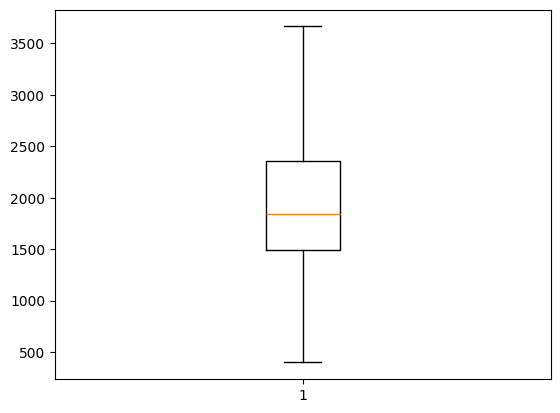

In [41]:
data['Living Area after Renovation (in Sqft)'] = data['Living Area after Renovation (in Sqft)'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['Living Area after Renovation (in Sqft)'])

In [42]:
Q1 = data['Lot Area after Renovation (in Sqft)'].quantile(0.25)
Q3 = data['Lot Area after Renovation (in Sqft)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(Q1,Q3,IQR,lower_bound,upper_bound)

5100.0 10083.0 4983.0 -2374.5 17557.5


In [43]:
for x in data['Lot Area after Renovation (in Sqft)']:
  if x <lower_bound or x > upper_bound:
    print(x)


101930
20336
30617
72513
18900
20158
38917
50529
35020
39750
135036
35065
47777
35001
88500
19265
87991
193842
18000
36590
35230
67268
50965
18386
20953
35096
80100
148539
18841
36224
33450
20060
47443
49385
19508
78408
57500
17958
35781
78408
20000
32156
19207
22654
17689
28399
44049
21455
24361
19868
19009
27743
22357
36852
143947
36497
18295
174240
211267
39480
21887
210394
75396
181319
50529
178160
233971
28837
49206
104374
24728
29170
20697
65340
107898
25346
98010
199504
165963
43560
32186
19400
35982
38255
26324
18000
213444
34589
21567
38312
41075
37034
23900
54885
33341
218222
34500
23680
63162
25792
33171
36149
36906
101529
18306
18503
28826
47916
27600
33900
213444
32417
32130
37891
19811
35160
75358
33447
21803
217800
44431
21810
44374
220654
94960
35021
83729
25545
27100
36728
20037
42882
40234
26788
26289
88519
26140
34787
213879
61011
41056
18615
24640
40089
93825
310582
37981
18512
23400
98010
18200
19350
28717
23035
47044
24619
38307
65340
69696
36626
100545
48000
3492

{'whiskers': [<matplotlib.lines.Line2D at 0x7a4d75ab9760>,
 'caps': [<matplotlib.lines.Line2D at 0x7a4d75ab9dc0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a4d75ab9430>],
 'medians': [<matplotlib.lines.Line2D at 0x7a4d75aba2a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a4d75aba4e0>],
 'means': []}

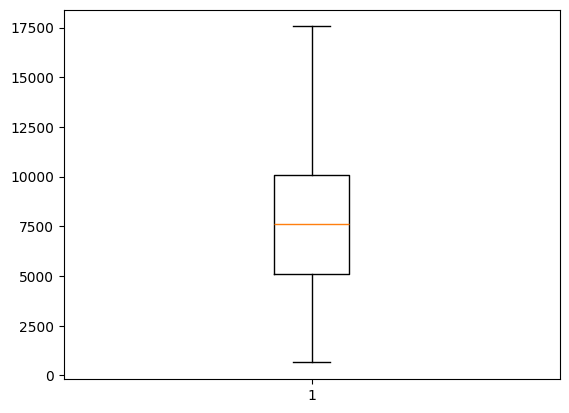

In [44]:
data['Lot Area after Renovation (in Sqft)'] = data['Lot Area after Renovation (in Sqft)'].clip(lower=lower_bound,upper = upper_bound)
plt.boxplot(data['Lot Area after Renovation (in Sqft)'])

Scaling Numerical Variables


Identify all numerical columns (excluding the target variable SalePrice).

Scale these features using techniques like Min-Max scaling or Standard scaling

In [45]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,StandardScaler

In [46]:
numeric_col = data.select_dtypes(include = ['int64','float64']).columns.drop('Sale Price')
numeric_col

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [47]:
stdScaler=StandardScaler()
data[numeric_col]=stdScaler.fit_transform(data[numeric_col])
data.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.886146,14 October 2017,221900.0,-0.424771,-1.521597,-1.046695,-0.605698,-0.915427,No,Twice,...,-0.595332,-0.771770,-0.681086,0.544898,-0.210128,1.870219,-0.352541,-0.306117,-0.978610,-0.606904
1,0.637511,14 December 2017,538000.0,-0.424771,0.209928,0.610390,-0.290710,0.936506,No,Twice,...,-0.595332,0.524266,0.278021,0.681079,4.746678,0.879619,1.161620,-0.746386,-0.439303,-0.151065
2,0.365444,15 February 2016,180000.0,-1.595614,-1.521597,-1.535476,0.254978,-0.915427,No,Twice,...,-1.593889,-1.308512,-0.681086,1.293892,-0.210128,-0.933365,1.283590,-0.135691,1.147801,-0.054122
3,-0.727656,14 December 2017,604000.0,0.746072,1.248843,-0.116820,-0.734305,-0.915427,No,Twice,...,-0.595332,-0.941956,1.500881,0.204446,-0.210128,1.085216,-0.283256,-1.271867,-0.947793,-0.755871
4,-0.912881,15 February 2016,510000.0,-0.424771,-0.136377,-0.450622,-0.124907,-0.915427,No,Twice,...,0.403225,-0.117206,-0.681086,-0.544548,-0.210128,-0.073599,0.409591,1.199316,-0.269807,-0.182233


Encoding Categorical Variables

Identify all categorical columns in the dataset.

Apply appropriate encoding techniques:

Use One-Hot Encoding for nominal categories.

Use Label Encoding for ordinal categories, if applicable.


In [48]:
cat_col = data.select_dtypes(include = ['object']).columns
cat_col

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

<Axes: xlabel='Condition of the House', ylabel='Count'>

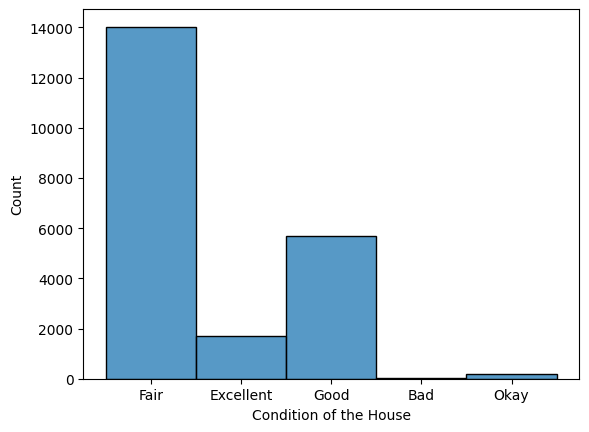

In [49]:
# histogram of Condition of the House.
sns.histplot(data = data, x = 'Condition of the House')

In [50]:
# No of Times Visited Values.
data['No of Times Visited'].unique()

array(['Twice', 'Thrice', 'Four', 'Once'], dtype=object)

In [51]:
# One-Hot encoding on Waterfront and Date House was Sold , Nominal Category.
data = pd.get_dummies(data,columns=['Waterfront View','Date House was Sold'],dtype = int)
data.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Condition of the House,Overall Grade,...,Date House was Sold_14 June 2017,Date House was Sold_14 May 2017,Date House was Sold_14 November 2017,Date House was Sold_14 October 2017,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016
0,0.886146,221900.0,-0.424771,-1.521597,-1.046695,-0.605698,-0.915427,Twice,Fair,-0.595332,...,0,0,0,1,0,0,0,0,0,0
1,0.637511,538000.0,-0.424771,0.209928,0.610390,-0.290710,0.936506,Twice,Fair,-0.595332,...,0,0,0,0,0,0,0,0,0,0
2,0.365444,180000.0,-1.595614,-1.521597,-1.535476,0.254978,-0.915427,Twice,Fair,-1.593889,...,0,0,0,0,0,0,1,0,0,0
3,-0.727656,604000.0,0.746072,1.248843,-0.116820,-0.734305,-0.915427,Twice,Excellent,-0.595332,...,0,0,0,0,0,0,0,0,0,0
4,-0.912881,510000.0,-0.424771,-0.136377,-0.450622,-0.124907,-0.915427,Twice,Fair,0.403225,...,0,0,0,0,0,0,1,0,0,0


In [52]:
print(data.filter(like='Waterfront View').head())

   Waterfront View_No  Waterfront View_Yes
0                   1                    0
1                   1                    0
2                   1                    0
3                   1                    0
4                   1                    0


In [53]:
# Label encoding on Condition of the House, Ordinal Category.
label_enc = LabelEncoder()
data['Condition of the House_new'] = label_enc.fit_transform(data['Condition of the House'])
data

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Condition of the House,Overall Grade,...,Date House was Sold_14 May 2017,Date House was Sold_14 November 2017,Date House was Sold_14 October 2017,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_new
0,0.886146,221900.0,-0.424771,-1.521597,-1.046695,-0.605698,-0.915427,Twice,Fair,-0.595332,...,0,0,1,0,0,0,0,0,0,2
1,0.637511,538000.0,-0.424771,0.209928,0.610390,-0.290710,0.936506,Twice,Fair,-0.595332,...,0,0,0,0,0,0,0,0,0,2
2,0.365444,180000.0,-1.595614,-1.521597,-1.535476,0.254978,-0.915427,Twice,Fair,-1.593889,...,0,0,0,0,0,1,0,0,0,2
3,-0.727656,604000.0,0.746072,1.248843,-0.116820,-0.734305,-0.915427,Twice,Excellent,-0.595332,...,0,0,0,0,0,0,0,0,0,1
4,-0.912881,510000.0,-0.424771,-0.136377,-0.450622,-0.124907,-0.915427,Twice,Fair,0.403225,...,0,0,0,0,0,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,-1.500888,360000.0,-0.424771,0.556233,-0.629444,-1.499812,2.788439,Twice,Fair,0.403225,...,1,0,0,0,0,0,0,0,0,2
21609,0.702159,400000.0,0.746072,0.556233,0.300431,-0.573447,0.936506,Twice,Fair,0.403225,...,0,0,0,0,0,1,0,0,0,2
21610,-1.062751,402101.0,-1.595614,-1.867902,-1.237439,-1.456481,0.936506,Twice,Fair,-0.595332,...,0,0,0,0,0,0,0,0,0,2
21611,-1.491046,400000.0,-0.424771,0.556233,-0.545993,-1.251106,0.936506,Twice,Fair,0.403225,...,0,0,0,0,0,0,1,0,0,2


In [54]:
# Label encoding on No of Times Visited, Ordinal Category.
label_enc = LabelEncoder()
data['No of Times Visited_new'] = label_enc.fit_transform(data['No of Times Visited'])
data

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Condition of the House,Overall Grade,...,Date House was Sold_14 November 2017,Date House was Sold_14 October 2017,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_new,No of Times Visited_new
0,0.886146,221900.0,-0.424771,-1.521597,-1.046695,-0.605698,-0.915427,Twice,Fair,-0.595332,...,0,1,0,0,0,0,0,0,2,3
1,0.637511,538000.0,-0.424771,0.209928,0.610390,-0.290710,0.936506,Twice,Fair,-0.595332,...,0,0,0,0,0,0,0,0,2,3
2,0.365444,180000.0,-1.595614,-1.521597,-1.535476,0.254978,-0.915427,Twice,Fair,-1.593889,...,0,0,0,0,1,0,0,0,2,3
3,-0.727656,604000.0,0.746072,1.248843,-0.116820,-0.734305,-0.915427,Twice,Excellent,-0.595332,...,0,0,0,0,0,0,0,0,1,3
4,-0.912881,510000.0,-0.424771,-0.136377,-0.450622,-0.124907,-0.915427,Twice,Fair,0.403225,...,0,0,0,0,1,0,0,0,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,-1.500888,360000.0,-0.424771,0.556233,-0.629444,-1.499812,2.788439,Twice,Fair,0.403225,...,0,0,0,0,0,0,0,0,2,3
21609,0.702159,400000.0,0.746072,0.556233,0.300431,-0.573447,0.936506,Twice,Fair,0.403225,...,0,0,0,0,1,0,0,0,2,3
21610,-1.062751,402101.0,-1.595614,-1.867902,-1.237439,-1.456481,0.936506,Twice,Fair,-0.595332,...,0,0,0,0,0,0,0,0,2,3
21611,-1.491046,400000.0,-0.424771,0.556233,-0.545993,-1.251106,0.936506,Twice,Fair,0.403225,...,0,0,0,0,0,1,0,0,2,3


Train-Test Split

Set aside the SalePrice column as the target variable.

Split the dataset into training (80%) and testing (20%) sets using the train_test_split function from sklearn.


In [55]:
y = data['Sale Price']
X= data.drop(columns=['Sale Price'])

In [56]:
X.columns

Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)', 'Waterfront View_No',
       'Waterfront View_Yes', 'Date House was Sold_14 August 2017',
       'Date House was Sold_14 December 2017',
       'Date House was Sold_14 July 2017', 'Date House was Sold_14 June 2017',
       'Date House was Sold_14 May 2017',
       'Date House was Sold_14 November 2017',
       'Date House was Sold_14 October 2017',
       'Date House was Sold_14 September 2017',
       'Date House was Sold_15 April 2016',
       'Date House was Sold_15 February 2016',
       'Date House was Sold_15 January 2016',
       'Dat

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
X_train.shape

(17290, 35)

In [59]:
X_test.shape

(4323, 35)

In [60]:
y_train.shape

(17290,)

In [61]:
y_test.shape

(4323,)

In [62]:
std_scalar = StandardScaler()

numeric_col = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[numeric_col] = std_scalar.fit_transform(X_train[numeric_col])
X_test[numeric_col] = std_scalar.transform(X_test[numeric_col])

X_train.head()


,ID,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Date House was Sold_14 November 2017,Date House was Sold_14 October 2017,Date House was Sold_14 September 2017,Date House was Sold_15 April 2016,Date House was Sold_15 February 2016,Date House was Sold_15 January 2016,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Condition of the House_new,No of Times Visited_new
6325,0.308395,-0.421691,-0.482538,-0.327654,0.878806,-0.919600,Twice,Good,1.406993,0.015927,...,-0.264685,-0.307315,-0.303807,-0.339617,-0.246051,-0.217940,-0.307315,-0.174864,1.380076,0.21558
13473,1.651581,-1.592472,-1.522028,-1.261290,-0.985502,-0.919600,Twice,Fair,-1.597071,-1.273279,...,-0.264685,-0.307315,-0.303807,-0.339617,-0.246051,-0.217940,3.253993,-0.174864,-0.334360,0.21558
17614,-0.755655,-0.421691,-1.522028,-1.165532,-0.234223,0.001545,Twice,Fair,-1.597071,-1.023331,...,-0.264685,-0.307315,-0.303807,-0.339617,4.064201,-0.217940,-0.307315,-0.174864,-0.334360,0.21558
16970,0.307974,-0.421691,0.210456,0.043406,-0.231445,-0.919600,Twice,Good,-0.595716,-0.641831,...,-0.264685,-0.307315,-0.303807,-0.339617,-0.246051,4.588417,-0.307315,-0.174864,1.380076,0.21558
20868,-0.540455,-1.592472,0.556952,-0.374336,-1.434167,0.922690,Twice,Fair,0.405638,-0.423456,...,-0.264685,-0.307315,-0.303807,2.944490,-0.246051,-0.217940,-0.307315,-0.174864,-0.334360,0.21558
